# Interpolation and Attribute-Specific editing

## Loading repository and enviroment

Before start do not forget to choose gpu runtime (Runtime -> Change runtime type -> T4 GPU)

In [1]:
import sys
sys.path.append("/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN")
from envs import actenv_jupyter, change_exp_dir
actenv_jupyter(cuda_version="12.9", gcc_version="11", clear_cache=False)

[actenv_jupyter] CUDA_HOME=/usr/local/cuda-12.9
[actenv_jupyter] TORCH_CUDA_ARCH_LIST=8.0
[actenv_jupyter] CXX=/usr/bin/g++-11 | CC=/usr/bin/gcc-11
[actenv_jupyter] Ready.


{'CUDA_HOME': '/usr/local/cuda-12.9',
 'TORCH_CUDA_ARCH_LIST': '8.0',
 'CC': '/usr/bin/gcc-11',
 'CXX': '/usr/bin/g++-11',
 'CUDAHOSTCXX': '/usr/bin/g++-11',
 'CXXFLAGS': '-std=c++17',
 'PATH_head': '/usr/local/cuda-12.9/bin:/home/ids/yuhe/anaconda3/envs/styleGANenv/bin:/home/ids/yuhe/.vscode-server/cli/servers/Stable-994fd12f8d3a5aa16f17d42c041e5809167e845a/server/bin/remote-cli',
 'LD_LIBRARY_PATH_head': '/usr/local/cuda-12.9/lib64:',
 'TORCH_CUDA_VERBOSE_BUILD': '1',
 'MAX_JOBS': '1'}

In [ ]:
from pathlib import Path

p = Path("/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/train_styleGAN2ada.tar.gz")

size_gb = p.stat().st_size / (1024**3)
size_gb




1.3417383534833789

In [ ]:
from pathlib import Path

# root = Path("/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/train_styleGAN2ada")

# size_bytes = sum(p.stat().st_size for p in root.rglob("*") if p.is_file())
# size_gb = size_bytes / (1024**3)
# size_gb


root = Path("/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/train_styleGAN2ada") 
size_bytes = sum(p.stat().st_size for p in root.rglob("*") if p.is_file()) 
size_gb = size_bytes / (1024**3) 
size_gb



1.355349144898355

In [ ]:
# cd /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed


# tar -czf train_styleGAN2ada_multiMod.tar.gz train_styleGAN2ada_multiMod


# scp -3   yuhe@gpu-gw:/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/train_styleGAN2ada_multiMod.tar.gz   usv51hl@jean-zay.idris.fr:/lustre/fsn1/projects/rech/hht/usv51hl/Projects/codes/datasets/BraTS/


# cd /lustre/fsn1/projects/rech/hht/usv51hl/Projects/codes/datasets/BraTS
# tar -xzf train_styleGAN2ada_multiMod.tar.gz


In [ ]:
import os
import random
import shutil

src = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/train_styleGAN2ada_multiMod"
dst = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/train_styleGAN2ada_multiMod_test"

os.makedirs(dst, exist_ok=True)

# list all files
files = [f for f in os.listdir(src) if os.path.isfile(os.path.join(src, f))]

# randomly pick 1000
selected = random.sample(files, 1000)

# copy
for f in selected:
    shutil.copy(os.path.join(src, f), dst)

print("Copied", len(selected), "images.")

# /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/train_styleGAN2ada_multiMod_test

# Medical_imaging/brats/Preprocessed/train_styleGAN2ada_multiMod

Copied 1000 images.


In [12]:
import os

path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/train_styleGAN2ada"
path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/train_styleGAN2ada_multiMod"

count = sum(
    1 for f in os.listdir(path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
)

print("Number of images:", count)


Number of images: 255204


In [7]:
50*1251

62550

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
img_dir = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/train_styleGAN2ada"

label_root_GLI = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/BraTS2023_GLI/TrainingData_nii/label"
label_root_MET = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/BraTS2023_MET/TrainingData_nii/label"
split_name = "bratsHT"
out_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/X_Y_splits/{split_name}"
os.makedirs(out_dir, exist_ok=True)

# thresholds
T_slice_healthy = 50      # <= healthy
T_slice_tumor   = 1500    # >= tumor

# slice depth range
SLICE_MIN = 60
SLICE_MAX = 100

# ---------------------------------------------------------
# CSV CACHE
# ---------------------------------------------------------
label_cache = {}

def get_labels_for_patient(patient_id):
    if patient_id in label_cache:
        return label_cache[patient_id]

    if patient_id.startswith("BraTS-GLI"):
        csv_path = os.path.join(label_root_GLI, f"{patient_id}-labels.csv")
    else:
        csv_path = os.path.join(label_root_MET, f"{patient_id}-labels.csv")

    df = pd.read_csv(csv_path)

    lookup = {}
    for _, row in df.iterrows():
        slice_name = row["Slice"]       # like "s87"
        k = int(slice_name[1:])         # -> 87
        lookup[k] = (
            int(row["0"]),
            int(row["1"]),
            int(row["2"]),
            int(row["3"])
        )

    label_cache[patient_id] = lookup
    return lookup

# ---------------------------------------------------------
# FILENAME PARSER
# ---------------------------------------------------------
def parse_png(filename):
    pid, rest = filename.split("_slice_")
    slice_id = int(rest.replace(".png", ""))
    return pid, slice_id

# ---------------------------------------------------------
# CLASSIFY SLICES
# ---------------------------------------------------------
files = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])

paths_healthy = []
paths_tumor = []

print(f"Found {len(files)} total PNG slices.")

for fname in files:
    full_path = os.path.join(img_dir, fname)

    patient_id, slice_id = parse_png(fname)

    # slice range
    if slice_id < SLICE_MIN or slice_id > SLICE_MAX:
        continue

    label_dict = get_labels_for_patient(patient_id)
    if slice_id not in label_dict:
        continue

    c0, c1, c2, c3 = label_dict[slice_id]
    tumor_pixels = c1 + c2 + c3

    if tumor_pixels <= T_slice_healthy:
        paths_healthy.append(full_path)
    elif tumor_pixels >= T_slice_tumor:
        paths_tumor.append(full_path)

print("Healthy found:", len(paths_healthy))
print("Tumor found:  ", len(paths_tumor))

# ---------------------------------------------------------
# BALANCE (make X = Y)
# ---------------------------------------------------------
N = min(len(paths_healthy), len(paths_tumor))
print("Balancing both classes to:", N)

np.random.shuffle(paths_healthy)
np.random.shuffle(paths_tumor)

paths_healthy = np.array(paths_healthy[:N])
paths_tumor   = np.array(paths_tumor[:N])

# ---------------------------------------------------------
# SPLIT
# ---------------------------------------------------------
train_X, test_X = train_test_split(paths_healthy, test_size=0.2, random_state=42)
train_Y, test_Y = train_test_split(paths_tumor,   test_size=0.2, random_state=42)

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------
np.save(os.path.join(out_dir, "train_X.npy"), train_X)
np.save(os.path.join(out_dir, "test_X.npy"),  test_X)
np.save(os.path.join(out_dir, "train_Y.npy"), train_Y)
np.save(os.path.join(out_dir, "test_Y.npy"),  test_Y)

# ---------------------------------------------------------
# SUMMARY
# ---------------------------------------------------------
print("\n==============================")
print("      FINAL DATA SUMMARY      ")
print("==============================")
print("Slice range used:", SLICE_MIN, "to", SLICE_MAX)
print("Healthy threshold (<=):", T_slice_healthy)
print("Tumor threshold (>=):  ", T_slice_tumor)

print("\nBalanced X:", len(paths_healthy))
print("Balanced Y:", len(paths_tumor))

print("\nTrain X:", len(train_X))
print("Test  X:", len(test_X))
print("Train Y:", len(train_Y))
print("Test  Y:", len(test_Y))
print("==============================\n")


Found 138477 total PNG slices.
Healthy found: 14511
Tumor found:   26052
Balancing both classes to: 14511

      FINAL DATA SUMMARY      
Slice range used: 60 to 100
Healthy threshold (<=): 50
Tumor threshold (>=):   1500

Balanced X: 14511
Balanced Y: 14511

Train X: 11608
Test  X: 2903
Train Y: 11608
Test  Y: 2903



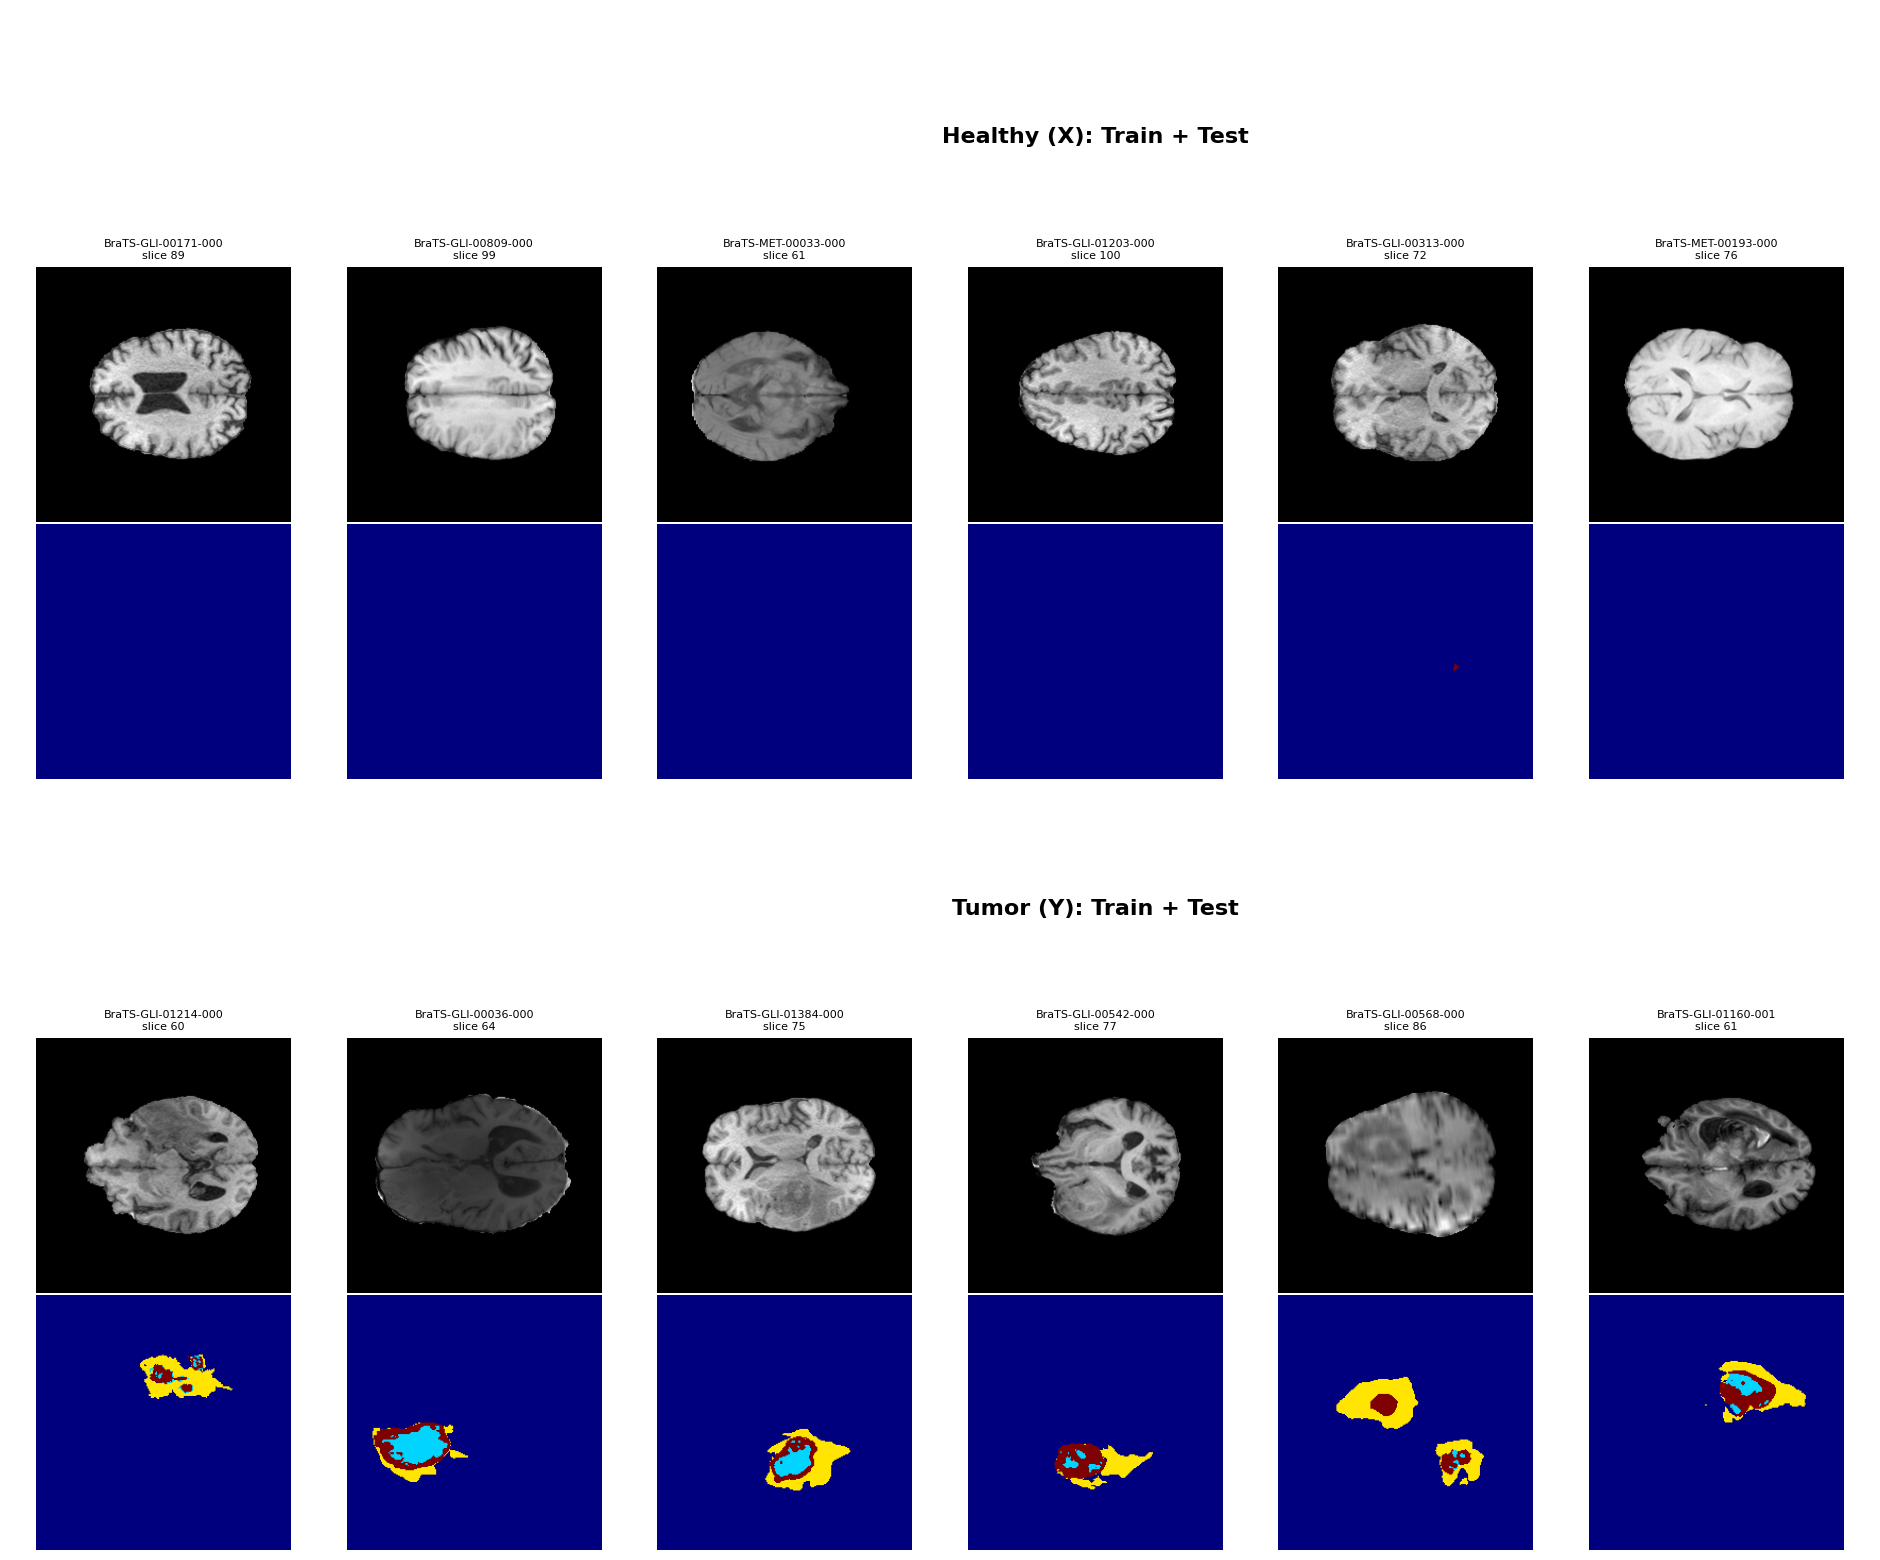

In [45]:
import os
import random
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from PIL import Image

# ---------------------------------------------------------
# LOAD SPLITS
split_name = "bratsHT"
split_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/X_Y_splits/{split_name}"

img_dir = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/train_styleGAN2ada"

seg_root_MET = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/BraTS2023_MET/TrainingData_nii/seg"
seg_root_GLI = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/BraTS2023_GLI/TrainingData_nii/seg"

train_X = np.load(os.path.join(split_dir, "train_X.npy"), allow_pickle=True)
test_X  = np.load(os.path.join(split_dir, "test_X.npy"),  allow_pickle=True)
train_Y = np.load(os.path.join(split_dir, "train_Y.npy"), allow_pickle=True)
test_Y  = np.load(os.path.join(split_dir, "test_Y.npy"),  allow_pickle=True)

# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------
N = 3   # Number for train and test in each group

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def parse_png_name(path):
    base = os.path.basename(path)
    pid = base.split("_slice_")[0]
    slice_id = int(base.split("_slice_")[1].replace(".png", ""))
    return pid, slice_id

def load_segmentation(patient_id):
    if patient_id.startswith("BraTS-GLI"):
        seg_path = os.path.join(seg_root_GLI, f"{patient_id}-seg.nii.gz")
    else:
        seg_path = os.path.join(seg_root_MET, f"{patient_id}-seg.nii.gz")
    return nib.load(seg_path).get_fdata()

def load_png(path):
    return np.array(Image.open(path))

# ---------------------------------------------------------
# RANDOMLY PICK EXACTLY N TRAIN + N TEST
# ---------------------------------------------------------
X_samples = random.sample(list(train_X), N) + random.sample(list(test_X), N)
Y_samples = random.sample(list(train_Y), N) + random.sample(list(test_Y), N)

# ---------------------------------------------------------
# VISUALIZATION WITH HEADERS
# ---------------------------------------------------------

num_cols = 2 * N
fig, axes = plt.subplots(6, num_cols, figsize=(4*num_cols, 20))
plt.subplots_adjust(hspace=0.01, wspace=0.01)

def visualize_images(paths, row_mri, row_mask):
    """Draw MRI and mask for given row indices."""
    for col, path in enumerate(paths):
        pid, sid = parse_png_name(path)

        img = load_png(path)
        seg = load_segmentation(pid)
        seg_slice = seg[:, :, sid]

        # MRI
        ax = axes[row_mri, col]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"{pid}\nslice {sid}", fontsize=8)
        ax.axis('off')

        # Mask
        ax = axes[row_mask, col]
        ax.imshow(seg_slice, cmap='jet')
        ax.axis('off')

# ---------------------------------------------------------
# Row 0: Header for Healthy
# ---------------------------------------------------------
for ax in axes[0]:
    ax.axis('off')
axes[0, num_cols//2].text(
    0.5, 0.5, 
    "Healthy (X): Train + Test", 
    ha='center', va='center', fontsize=16, fontweight='bold'
)

# ---------------------------------------------------------
# Rows 1–2: Healthy image + mask
# ---------------------------------------------------------
visualize_images(X_samples, row_mri=1, row_mask=2)

# ---------------------------------------------------------
# Row 3: Header for Tumor
# ---------------------------------------------------------
for ax in axes[3]:
    ax.axis('off')
axes[3, num_cols//2].text(
    0.5, 0.5, 
    "Tumor (Y): Train + Test",
    ha='center', va='center', fontsize=16, fontweight='bold'
)

# ---------------------------------------------------------
# Rows 4–5: Tumor image + mask
# ---------------------------------------------------------
visualize_images(Y_samples, row_mri=4, row_mask=5)

plt.show()



In [8]:
import pandas as pd
import os

def get_brats_label_from_png(png_path):
    """
    Given a PNG path like:
        BraTS-GLI-00009-001_slice_063.png
    return the corresponding row in:
        BraTS-GLI-00009-001-labels.csv
    """

    # Extract file name only
    base = os.path.basename(png_path)

    # Example: BraTS-GLI-00009-001_slice_063.png
    # Split into patient ID + slice index
    # base.split("_") → ['BraTS-GLI-00009-001', 'slice', '063.png']
    parts = base.split("_")

    patient_id = parts[0]     # 'BraTS-GLI-00009-001'
    slice_id = int(parts[2].replace(".png", ""))  # 63

    # Build full CSV path
    csv_path = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/BraTS2023_GLI/TrainingData_nii/label/{patient_id}-labels.csv"

    # Load CSV
    df = pd.read_csv(csv_path)

    # The slice in CSV is s0, s1, ..., so look for s63
    key = f"s{slice_id}"

    row = df[df["Slice"] == key]

    if row.empty:
        raise ValueError(f"No label found for slice {slice_id} in {csv_path}")

    return row.iloc[0]   # return pandas Series (label counts)


In [9]:
png = "/home/.../BraTS-GLI-00009-001_slice_063.png"

label_row = get_brats_label_from_png(png)
print(label_row)


Slice      s63
0        14283
1            0
2            0
3            0
Name: 63, dtype: object


In [ ]:
# import os
# import shutil

# # ---------------------------
# # PATHS
# # ---------------------------
# raw_root = "/home/ids/yuhe/Shared/Data/Brain_MRI_Datasets/BraTS2023/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
# out_root = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/BraTS2023_GLI/TrainingData_nii"

# modalities = {
#     # "t1n": "-t1n.nii.gz",
#     "t1c": "-t1c.nii.gz",
#     "t2f": "-t2f.nii.gz",
#     "t2w": "-t2w.nii.gz",
# }

# # Create output folders
# for m in modalities.keys():
#     os.makedirs(os.path.join(out_root, m), exist_ok=True)

# # ---------------------------
# # COPY LOOP
# # ---------------------------
# patients = sorted(os.listdir(raw_root))

# for pid in patients:
#     patient_folder = os.path.join(raw_root, pid)

#     if not os.path.isdir(patient_folder):
#         continue

#     for m, suffix in modalities.items():
#         src = os.path.join(patient_folder, pid + suffix)
#         dst = os.path.join(out_root, m, pid + suffix)

#         if os.path.exists(src):
#             shutil.copy(src, dst)
#             print(f"Copied: {src} -> {dst}")
#         else:
#             print(f"[MISSING] {src}")

# print("\nDONE copying all modalities!")


Copied: /home/ids/yuhe/Shared/Data/Brain_MRI_Datasets/BraTS2023/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1c.nii.gz -> /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/BraTS2023_GLI/TrainingData_nii/t1c/BraTS-GLI-00000-000-t1c.nii.gz
Copied: /home/ids/yuhe/Shared/Data/Brain_MRI_Datasets/BraTS2023/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t2f.nii.gz -> /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/BraTS2023_GLI/TrainingData_nii/t2f/BraTS-GLI-00000-000-t2f.nii.gz
Copied: /home/ids/yuhe/Shared/Data/Brain_MRI_Datasets/BraTS2023/BraTS-GLI/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t2w.nii.gz -> /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/BraTS2023_GLI/TrainingData_nii/t2w/BraTS-GLI-00000-000-t2w.nii.gz
Copied: /h